In [145]:
"""
EEG → 4D Tensor Pipeline  (CWT-based, micro-arousal resolution)
================================================================
CAP Sleep Dataset — 6 bipolar channels
    F1-F3, F2-F4, F3-C3, F4-C4, P3-O1, P4-O2
 
Architecture
------------
  60-second epoch
      └── CWT on each channel  →  (n_freqs × n_timepoints) power matrix
              └── split into 1-second slices
                      └── average CWT power per freq-band per slice
                              └── RBF interpolation onto 32×32 scalp grid
                                      └── coolwarm RGB  (blue=low, red=high)
 
Final tensor per epoch:  (n_slices, H, W, 3)
    n_slices = 60   (one per second, 60s epoch)
    H = W    = 32   (spatial grid)
    3               = RGB
 
Why CWT catches micro arousals
-------------------------------
Welch collapses a 30s window into 1 number — a 3s arousal is averaged away.
CWT produces power at every frequency at every moment in time.
A micro arousal (3-15s, AASM) shows up as a localised burst in the
CWT matrix and survives into its own 1-second slice in the cube.
 
How CWT power (PSD) is computed
---------------------------------
1. Choose target frequencies  f₁ … fₙ  (log-spaced, 0.5–45 Hz)
2. For each frequency f:
      scale  s = (wavelet_centre_freq × sfreq) / f
      convolve signal with Morlet wavelet at scale s
      → complex coefficient c(t) at every timepoint t
      instantaneous power at f,t = |c(t)|²
3. Stack → CWT matrix  P(f, t)  shape (n_freqs, n_timepoints)
4. For each 1-second window [t₀, t₀+sfreq]:
      band_power = mean( P[freq_band_rows, t₀:t₀+sfreq] )
   → one scalar per channel per 1-second slice
5. That scalar feeds the RBF interpolator → RGB topomap frame
"""
 
import numpy as np
import mne
import pywt                                        # pip install PyWavelets
from scipy.interpolate import RBFInterpolator
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D

In [146]:
ELECTRODE_10_20 = {
    "FP1": (-0.18,  0.85), "FP2": ( 0.18,  0.85),
    "F7":  (-0.72,  0.45), "F8":  ( 0.72,  0.45),
    "F3":  (-0.35,  0.50), "F4":  ( 0.35,  0.50),
    "F1":  (-0.18,  0.52), "F2":  ( 0.18,  0.52),
    "FZ":  ( 0.00,  0.50),
    "T3":  (-0.85,  0.00), "T4":  ( 0.85,  0.00),
    "C3":  (-0.50,  0.00), "C4":  ( 0.50,  0.00),
    "CZ":  ( 0.00,  0.00),
    "P3":  (-0.35, -0.50), "P4":  ( 0.35, -0.50),
    "PZ":  ( 0.00, -0.50),
    "O1":  (-0.30, -0.85), "O2":  ( 0.30, -0.85),
    "A1":  (-1.00,  0.00), "A2":  ( 1.00,  0.00),
    "ROC": ( 0.90,  0.30), "LOC": (-0.90,  0.30),  # EOG outer canthi
}
 
# EEG channels present in CAP n1.edf (excludes EMG/ECG/HR/SpO2/respiratory)
CAP_EEG_CHANNELS = [
    "F1-F3", "F2-F4",
    "F3-C3", "F4-C4",
    "C3-P3", "C4-P4",
    "P3-O1", "P4-O2",
    "C4-A1",
]
 
def resolve_position(ch_name):
    """
    Return (x, y) scalp coordinate for a channel name.
    Handles monopolar ('F3') and bipolar ('F3-C3') names.
    Bipolar → midpoint of the two electrode positions.
    """
    name = ch_name.upper().strip()
    if name in ELECTRODE_10_20:
        return ELECTRODE_10_20[name]
    if "-" in name:
        parts = name.split("-", 1)
        pts   = [np.array(ELECTRODE_10_20[p.strip()])
                 for p in parts if p.strip() in ELECTRODE_10_20]
        if len(pts) == 2:
            return tuple(((pts[0] + pts[1]) / 2).tolist())
        if len(pts) == 1:
            return tuple(pts[0].tolist())
    print(f"  [warn] Unknown channel '{ch_name}' → (0, 0)")
    return (0.0, 0.0)
 

In [147]:
def load_edf(edf_path, target_channels=None, resample_hz=100.0):
    """
    Load EDF, pick only EEG channels by name, convert V → µV,
    bandpass 0.5–45 Hz, resample.
 
    Why we convert V → µV
    ----------------------
    MNE returns data in Volts. EEG amplitudes (~400 µV) stored as Volts
    are ~0.0004. Their variance is ~1e-8. Non-EEG channels like HR (~70)
    and SpO2 (~94) have variance ~50. If we mix units, HR/SpO2 dominate
    every power calculation by a factor of ~5 billion and the EEG signal
    is invisible. Multiplying EEG by 1e6 brings variance into the range
    100–50000 µV², which is the correct physiological range.
 
    Returns
    -------
    data     : (n_channels, n_samples)  float64  in µV
    sfreq    : float
    ch_names : list of str
    """
    if target_channels is None:
        target_channels = CAP_EEG_CHANNELS
 
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
 
    # explicit name-based pick — never fall back to pick_types
    # because MNE labels HR/SpO2 as EEG in CAP EDFs (wrong type tags)
    raw_lower = {c.lower(): c for c in raw.ch_names}
    picked = []
    for ch in target_channels:
        key = ch.lower()
        if key in raw_lower:
            picked.append(raw_lower[key])
        else:
            match = next((v for k, v in raw_lower.items() if key in k), None)
            if match:
                picked.append(match)
 
    if not picked:
        raise ValueError(
            f"None of {target_channels} found.\nAvailable: {raw.ch_names}"
        )
 
    raw.pick_channels(picked)
    raw.filter(0.5, 45.0, fir_design="firwin", verbose=False)
    if abs(raw.info["sfreq"] - resample_hz) > 1.0:
        raw.resample(resample_hz, verbose=False)
 
    data = raw.get_data() * 1e6   # V → µV
 
    print(f"  Channels  : {raw.ch_names}")
    print(f"  sfreq     : {raw.info['sfreq']} Hz")
    print(f"  Duration  : {raw.n_times / raw.info['sfreq']:.1f} s")
    print(f"  Amplitude : {data.min():.1f} – {data.max():.1f} µV  "
          f"(healthy EEG ≈ ±20–500 µV)")
 
    return data, raw.info["sfreq"], raw.ch_names

In [148]:
def slice_epochs(data, sfreq, epoch_sec=60.0):
    """
    Cut continuous EEG into non-overlapping fixed-length epochs.
 
    Returns
    -------
    epochs : (n_epochs, n_channels, epoch_samples)
    """
    samples_per_epoch = int(epoch_sec * sfreq)
    n_epochs          = data.shape[1] // samples_per_epoch
    trimmed           = data[:, :n_epochs * samples_per_epoch]
    # (n_ch, n_epochs, samples) → (n_epochs, n_ch, samples)
    return trimmed.reshape(data.shape[0], n_epochs, samples_per_epoch) \
                  .transpose(1, 0, 2)

In [149]:
CWT_FREQS = np.logspace(np.log10(0.5), np.log10(45.0), num=40)
 
# EEG frequency bands for labelling / optional per-band power
BANDS = {
    "delta": (0.5,  4.0),
    "theta": (4.0,  8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
    "gamma": (30.0, 45.0),
}
 
def cwt_power_matrix(signal, sfreq, freqs=CWT_FREQS):
    """
    Compute CWT instantaneous power for one channel signal.
 
    How it works
    ------------
    For each target frequency f:
      1. Compute the wavelet scale:  scale = (ψ_centre_freq × sfreq) / f
         where ψ_centre_freq is the centre frequency of the Morlet wavelet
         (≈ 0.8125 Hz for PyWavelets 'cmor1.5-1.0')
      2. Convolve the signal with the Morlet wavelet at that scale
         → complex coefficient array  c(t)  for every timepoint t
      3. Instantaneous power at frequency f, time t  =  |c(t)|²
 
    Parameters
    ----------
    signal : (n_samples,)  one channel, one epoch
    sfreq  : sampling frequency in Hz
    freqs  : target frequencies in Hz  (length n_freqs)
 
    Returns
    -------
    power  : (n_freqs, n_samples)  instantaneous power  (µV²)
    """
    wavelet    = "cmor1.5-1.0"          # complex Morlet, bandwidth=1.5, fc=1.0
    centre_f   = pywt.central_frequency(wavelet)           # ≈ 1.0 Hz
    scales     = (centre_f * sfreq) / freqs               # one scale per freq
 
    # pywt.cwt returns (n_scales, n_samples) complex coefficients
    coeffs, _  = pywt.cwt(signal, scales, wavelet, sampling_period=1.0/sfreq)
    power      = np.abs(coeffs) ** 2                      # (n_freqs, n_samples)
    return power
 
 
def epoch_to_cwt_slices(epoch, sfreq, slice_sec=1.0, freqs=CWT_FREQS):
    """
    Convert one epoch (n_channels × epoch_samples) into a
    per-slice PSD matrix using CWT.
 
    For each channel:
      1. Compute CWT power matrix  (n_freqs × epoch_samples)
      2. Split time axis into slice_sec-second windows
      3. Average power across all frequencies within each window
         → one scalar (broadband power) per slice
 
    Parameters
    ----------
    epoch     : (n_channels, epoch_samples)
    sfreq     : Hz
    slice_sec : duration of each time slice in seconds (1 or 2)
    freqs     : target CWT frequencies
 
    Returns
    -------
    slice_psd : (n_slices, n_channels)
                Mean CWT power per slice per channel
    """
    n_ch, n_samples   = epoch.shape
    slice_samples     = int(slice_sec * sfreq)
    n_slices          = n_samples // slice_samples
 
    slice_psd = np.zeros((n_slices, n_ch), dtype=np.float32)
 
    for ch in range(n_ch):
        power = cwt_power_matrix(epoch[ch], sfreq, freqs)   # (n_freqs, n_samples)
 
        for s in range(n_slices):
            t0 = s * slice_samples
            t1 = t0 + slice_samples
            # mean power across all freqs and all timepoints in this slice
            slice_psd[s, ch] = power[:, t0:t1].mean()
 
    return slice_psd    # (n_slices, n_channels)

In [150]:
def psd_to_rgb(psd_row, ch_names, grid_size, vmin, vmax):
    """
    Interpolate one PSD row (n_channels,) onto a (grid_size, grid_size, 3)
    RGB image.
 
    Steps
    -----
    1. Look up (x, y) scalp coordinate for each channel
    2. RBF thin-plate-spline interpolation from 6 electrode points
       onto the full grid_size × grid_size grid
    3. Normalise to [0, 1] using global vmin/vmax
    4. Map through coolwarm colormap:  0 → blue,  1 → red
    5. Zero out pixels outside the scalp disc (unit circle)
    """
    xy = np.array([resolve_position(ch) for ch in ch_names])
 
    lin      = np.linspace(-1.0, 1.0, grid_size)
    gx, gy   = np.meshgrid(lin, lin)
    grid_pts = np.column_stack([gx.ravel(), gy.ravel()])
    scalp    = (gx**2 + gy**2) <= 1.0
 
    interp  = RBFInterpolator(xy, psd_row, kernel="thin_plate_spline",
                               smoothing=1e-3)
    values  = interp(grid_pts).reshape(grid_size, grid_size)
    values = np.clip(values, psd_row.min(), psd_row.max())
    normed  = np.clip((values - vmin) / (vmax - vmin + 1e-12), 0.0, 1.0)
 
    rgb     = cm.get_cmap("coolwarm")(normed)[:, :, :3].astype(np.float32)
    rgb[~scalp] = 0.0
    return rgb

In [151]:
def epoch_to_tensor(epoch, sfreq, ch_names,
                    slice_sec=1.0, grid_size=32, freqs=CWT_FREQS,
                    vmin=None, vmax=None):
    """
    Full pipeline for one epoch:
        (n_ch, epoch_samples)
            → CWT slices  (n_slices, n_ch)
            → RGB frames  (n_slices, H, W, 3)
 
    Global normalisation: vmin/vmax computed across ALL slices of this epoch
    so colours are consistent within the cube.
 
    Returns
    -------
    tensor : (n_slices, grid_size, grid_size, 3)  float32
    """
    slice_psd = epoch_to_cwt_slices(epoch, sfreq, slice_sec, freqs)
    # (n_slices, n_ch)
 
    # if global vmin/vmax provided use them; else normalise within this epoch
    _vmin = slice_psd.min() if vmin is None else vmin
    _vmax = slice_psd.max() if vmax is None else vmax
 
    n_slices = slice_psd.shape[0]
    tensor   = np.zeros((n_slices, grid_size, grid_size, 3), dtype=np.float32)
 
    for s in range(n_slices):
        tensor[s] = psd_to_rgb(slice_psd[s], ch_names, grid_size, _vmin, _vmax)
 
    return tensor, slice_psd   # (n_slices, H, W, 3)  +  raw PSD for inspection

In [152]:
def plot_epoch_cube(tensor, epoch_idx, slice_sec, title=None):
    """
    Two views of one epoch's 4D tensor:
 
    View 1 — 3D stacked planes (interactive, rotatable)
        X, Y = spatial scalp axes
        Z    = time within the epoch (each plane = slice_sec seconds)
        RGB  = CWT power intensity
 
    View 2 — flat grid of topomaps
        Every slice laid out left-to-right, top-to-bottom
        Best for spotting which exact seconds contain a micro arousal
    """
    n_slices, H, W, _ = tensor.shape
    t_labels = [f"{s * slice_sec:.0f}s" for s in range(n_slices)]
 
    if title is None:
        title = (f"Epoch {epoch_idx}  |  "
                 f"{n_slices} × {slice_sec}s slices  |  "
                 f"CWT broadband power")
 
    # ── View 1: 3D cube ───────────────────────────────────────────────────
    fig1 = plt.figure(figsize=(13, 9))
    ax   = fig1.add_subplot(111, projection="3d")
 
    xs = np.arange(W)
    ys = np.arange(H)
    xx, yy = np.meshgrid(xs, ys)
 
    # z=0,1,...,n_slices-1  — flush, no gaps between slices
    z_positions = np.arange(n_slices, dtype=float)
 
    for s in range(n_slices):
        frame   = tensor[s]
        zz      = np.full_like(xx, float(s), dtype=float)
        outside = (frame.sum(axis=-1) == 0.0)
 
        rgba              = np.ones((H, W, 4), dtype=np.float32)
        rgba[:, :, :3]    = frame
        rgba[outside,  3] = 0.0    # transparent outside scalp disc
        rgba[~outside, 3] = 0.06   # very low alpha — see through full stack;
                                   # persistent activity accumulates visually
 
        ax.plot_surface(xx, yy, zz,
                        facecolors=rgba,
                        rstride=1, cstride=1,
                        antialiased=False, shade=False)
 
    ax.set_xlabel("X  (spatial)")
    ax.set_ylabel("Y  (spatial)")
    ax.set_zlabel("Z  (seconds within epoch)")
 
    tick_step = max(1, n_slices // 12)
    ax.set_zticks(z_positions[::tick_step])
    ax.set_zticklabels(t_labels[::tick_step], fontsize=7)
 
    ax.set_title(title, fontsize=10, pad=14)
    ax.view_init(elev=25, azim=-60)
 
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(0, 1))
    sm.set_array([])
    fig1.colorbar(sm, ax=ax, shrink=0.4, pad=0.12,
                  label="Normalised CWT power  (blue=low | red=high)")
 
    # ── View 2: grid of topomaps ──────────────────────────────────────────
    ncols = 10
    nrows = int(np.ceil(n_slices / ncols))
    fig2, axes = plt.subplots(nrows, ncols,
                               figsize=(ncols * 1.8, nrows * 1.9))
    fig2.suptitle(f"{title}\n— each panel = {slice_sec}s —", fontsize=9)
    axes = axes.ravel()
 
    for s in range(n_slices):
        axes[s].imshow(tensor[s], origin="upper", interpolation="bilinear")
        axes[s].set_title(t_labels[s], fontsize=7)
        axes[s].axis("off")
 
    for j in range(n_slices, len(axes)):
        axes[j].axis("off")
 
    sm2 = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(0, 1))
    sm2.set_array([])
    fig2.colorbar(sm2, ax=axes.tolist(), orientation="vertical",
                  fraction=0.012, pad=0.02,
                  label="Normalised CWT power")
 
    plt.tight_layout()
    plt.show()


Loading   : n1.edf


C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\3722326933.py:24: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\3722326933.py:24: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\3722326933.py:24: RuntimeWarning: Highpass cutoff frequency 10.0 is greater than lowpass cutoff frequency 3.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Channels  : ['F1-F3', 'F2-F4', 'F3-C3', 'F4-C4', 'C3-P3', 'C4-P4', 'P3-O1', 'P4-O2', 'C4-A1']
  sfreq     : 100.0 Hz
  Duration  : 34620.0 s
  Amplitude : -768.1 – 696.3 µV  (healthy EEG ≈ ±20–500 µV)

Slicing into 60.0s epochs ...
  Total epochs : 577
  Time covered : 9.62 hours

Processing epoch 1  [1.0 min → 2.0 min] ...
  CWT freqs    : 0.5 – 45.0 Hz  (40 log-spaced)
  Slice size   : 1.0s  →  60 slices per cube
  Computing percentile power range across all epochs ...


C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\3146661478.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb     = cm.get_cmap("coolwarm")(normed)[:, :, :3].astype(np.float32)


  Percentile range   :  p1  = 5.1697e+01
                        p99 = 2.6796e+03
  Absolute max       :       8.3322e+03  (was anchoring everything else to look blue)

  Tensor shape     : (60, 32, 32, 3)  (slices=60, H=32, W=32, RGB=3)
  Epoch PSD range  : 8.5050e+00 – 2.2342e+05
  Position in scale: 64.0%  (0%=blue / 50%=white / 100%=red)


C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\1347210708.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


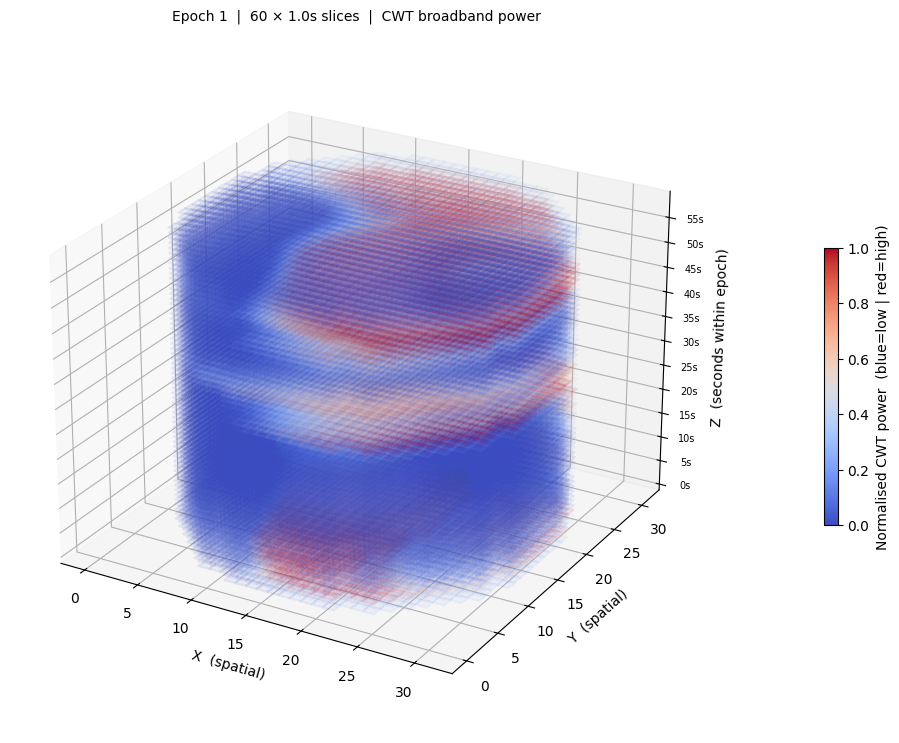

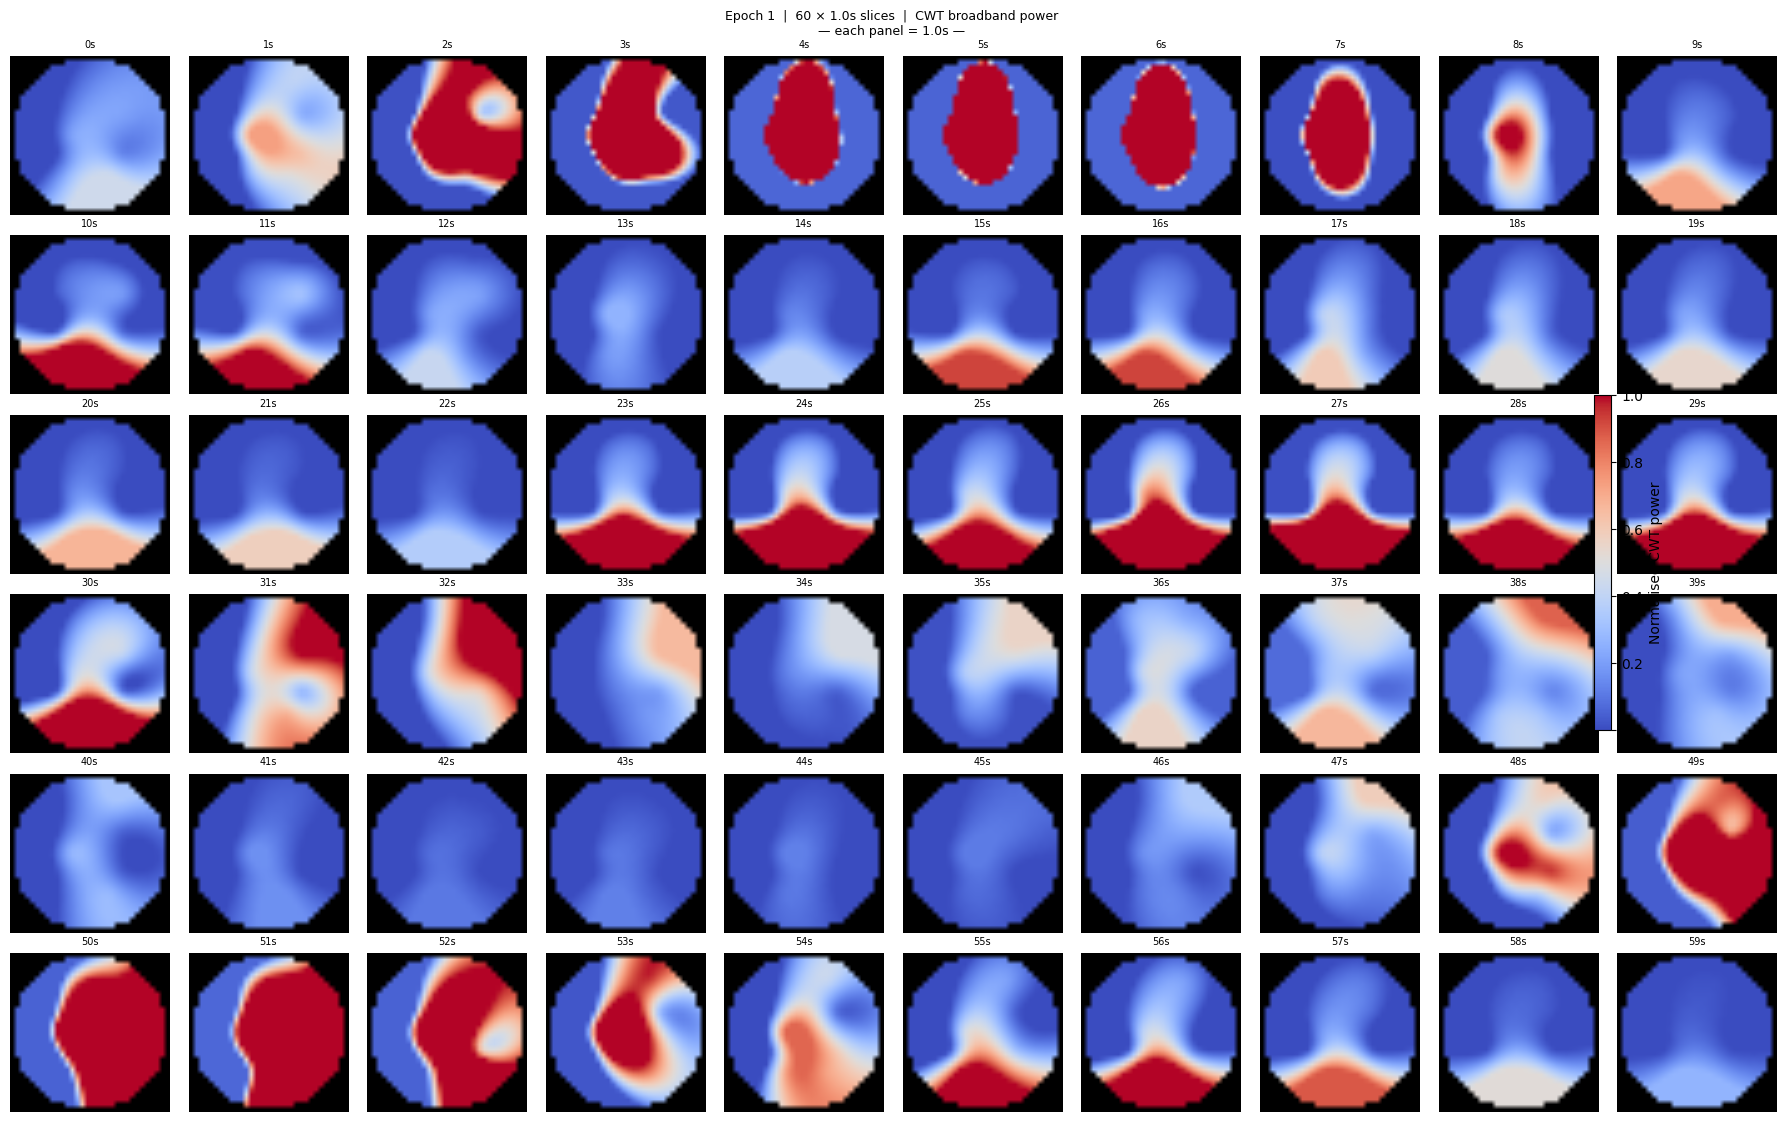

In [153]:
def run(edf_path,
        epoch_sec  = 60.0,   # 60-second epochs
        slice_sec  = 1.0,    # 1-second CWT slices  →  60 slices per cube
        grid_size  = 32,
        epoch_idx  = 0):     # which epoch to visualise (0 = first)
    """
    Parameters
    ----------
    edf_path  : path to CAP .edf file
    epoch_sec : epoch length in seconds (60 recommended)
    slice_sec : CWT slice length — 1s catches micro arousals (3-15s AASM)
    grid_size : spatial resolution of each topomap frame
    epoch_idx : which 60-second epoch to visualise
                change this to inspect different parts of the recording
    """
    print(f"\nLoading   : {edf_path}")
    data, sfreq, ch_names = load_edf(edf_path)
 
    print(f"\nSlicing into {epoch_sec}s epochs ...")
    epochs = slice_epochs(data, sfreq, epoch_sec)
    n_epochs = epochs.shape[0]
    print(f"  Total epochs : {n_epochs}")
    print(f"  Time covered : {n_epochs * epoch_sec / 3600:.2f} hours")
 
    if epoch_idx >= n_epochs:
        raise ValueError(f"epoch_idx={epoch_idx} out of range (0–{n_epochs-1})")
 
    t_start = epoch_idx * epoch_sec
    t_end   = t_start + epoch_sec
    print(f"\nProcessing epoch {epoch_idx}  "
          f"[{t_start/60:.1f} min → {t_end/60:.1f} min] ...")
    print(f"  CWT freqs    : {CWT_FREQS[0]:.1f} – {CWT_FREQS[-1]:.1f} Hz  "
          f"({len(CWT_FREQS)} log-spaced)")
    print(f"  Slice size   : {slice_sec}s  →  "
          f"{int(epoch_sec / slice_sec)} slices per cube")
 
    # ── percentile-based global normalisation ────────────────────────────
    # Problem with absolute max: one loud artifact anchors the scale and
    # everything else looks blue.
    # Solution: use the 1st–99th percentile of signal variance across all
    # epochs. This spreads the colour scale across the TYPICAL power range
    # of the recording so genuine sleep events show as red/warm colours.
    print("  Computing percentile power range across all epochs ...")
    all_vars = np.var(epochs, axis=2).mean(axis=1)   # (n_epochs,) variance proxy
 
    # compute CWT PSD on the target epoch to get real scale factor
    epoch      = epochs[epoch_idx]
    _, ref_psd = epoch_to_tensor(epoch, sfreq, ch_names,
                                  slice_sec=slice_sec, grid_size=grid_size)
    ref_var    = all_vars[epoch_idx]
    scale      = ref_psd.mean() / (ref_var + 1e-12)
 
    # percentile anchoring — 1st percentile → blue, 99th percentile → red
    # anything above 99th (artifacts, movement) clips to red
    # anything below 1st  (true silence) clips to blue
    g_vmin = float(np.percentile(all_vars, 1))  * scale
    g_vmax = float(np.percentile(all_vars, 99)) * scale
 
    print(f"  Percentile range   :  p1  = {g_vmin:.4e}")
    print(f"                        p99 = {g_vmax:.4e}")
    print(f"  Absolute max       :       {all_vars.max() * scale:.4e}  "
          f"(was anchoring everything else to look blue)")
 
    # ── build tensor with percentile colour scale ─────────────────────────
    tensor, slice_psd = epoch_to_tensor(epoch, sfreq, ch_names,
                                         slice_sec=slice_sec,
                                         grid_size=grid_size,
                                         vmin=g_vmin, vmax=g_vmax)
 
    print(f"\n  Tensor shape     : {tensor.shape}  "
          f"(slices={tensor.shape[0]}, H={tensor.shape[1]}, "
          f"W={tensor.shape[2]}, RGB=3)")
    print(f"  Epoch PSD range  : {slice_psd.min():.4e} – {slice_psd.max():.4e}")
    frac = (slice_psd.mean() - g_vmin) / (g_vmax - g_vmin + 1e-12)
    print(f"  Position in scale: {100*frac:.1f}%  "
          f"(0%=blue / 50%=white / 100%=red)")
 
    plot_epoch_cube(tensor, epoch_idx, slice_sec)
 
 
# ── set epoch_idx to any value from 0 to (total_epochs - 1) ──────────────
run("n1.edf", epoch_sec=60.0, slice_sec=1.0, epoch_idx=1)

In [122]:
def scan_power(edf_path, epoch_sec=60.0, top_n=10):
    """
    Quickly scan all epochs using raw signal variance (no CWT) to find
    which epochs have the highest broadband power.
    Variance is a fast proxy for power — no wavelet needed.
 
    Prints a ranked table and plots a power timeline so you can
    immediately see where the red clouds will be.
 
    Parameters
    ----------
    edf_path  : path to EDF file
    epoch_sec : same epoch length you use in run()
    top_n     : how many top epochs to report
    """
    print(f"\nScanning  : {edf_path}")
    data, sfreq, ch_names = load_edf(edf_path)
 
    epochs   = slice_epochs(data, sfreq, epoch_sec)
    n_epochs = epochs.shape[0]
 
    # mean variance across all channels per epoch — fast power proxy
    # shape: (n_epochs,)
    epoch_power = np.var(epochs, axis=2).mean(axis=1)
 
    # ── ranked table ──────────────────────────────────────────────────────
    ranked = np.argsort(epoch_power)[::-1]   # highest first
 
    print(f"\n{'Rank':<6} {'epoch_idx':<12} {'time (min)':<18} {'power (var)':<14}")
    print("─" * 52)
    for rank, idx in enumerate(ranked[:top_n]):
        t_min = idx * epoch_sec / 60.0
        print(f"{rank+1:<6} {idx:<12} "
              f"{t_min:.1f} – {t_min + epoch_sec/60:.1f} min    "
              f"{epoch_power[idx]:.4e}")
 
    # ── timeline plot ─────────────────────────────────────────────────────
    minutes = np.arange(n_epochs) * epoch_sec / 60.0
 
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.fill_between(minutes, epoch_power, alpha=0.4, color="steelblue")
    ax.plot(minutes, epoch_power, color="steelblue", linewidth=0.8)
 
    # mark top_n epochs with red vertical lines
    for idx in ranked[:top_n]:
        t_min = idx * epoch_sec / 60.0
        ax.axvline(t_min, color="red", linewidth=1.2, alpha=0.8)
 
    ax.set_xlabel("Time (minutes)")
    ax.set_ylabel("Mean signal variance  (power proxy)")
    ax.set_title(f"{edf_path}  —  Power timeline\n"
                 f"Red lines = top {top_n} highest-power epochs → visualise these first")
    ax.set_xlim(0, minutes[-1])
    plt.tight_layout()
    plt.show()
 
    print(f"\n→ Run these epoch_idx values to find red clouds:")
    print(f"  {list(ranked[:top_n])}")
 
    return ranked[:top_n].tolist()


Scanning  : n1.edf


C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\1114922158.py:11: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\1114922158.py:11: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\1114922158.py:11: RuntimeWarning: Highpass cutoff frequency 10.0 is greater than lowpass cutoff frequency 3.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


  Channels : ['ROC-LOC', 'LOC-ROC', 'F2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'C4-A1', 'EMG1-EMG2', 'ECG1-ECG2', 'TERMISTORE', 'TORACE', 'ADDOME', 'Dx1-DX2', 'SX1-SX2', 'Posizione', 'HR', 'SpO2']
  sfreq    : 100.0 Hz
  Duration : 34620.0 s

Rank   epoch_idx    time (min)         power (var)   
────────────────────────────────────────────────────
1      1            1.0 – 2.0 min    7.5503e+00
2      0            0.0 – 1.0 min    4.8772e+00
3      576          576.0 – 577.0 min    4.4134e+00
4      393          393.0 – 394.0 min    3.0193e+00
5      105          105.0 – 106.0 min    2.9460e+00
6      78           78.0 – 79.0 min    2.8747e+00
7      356          356.0 – 357.0 min    2.8094e+00
8      525          525.0 – 526.0 min    2.8062e+00
9      298          298.0 – 299.0 min    2.7563e+00
10     369          369.0 – 370.0 min    2.6200e+00


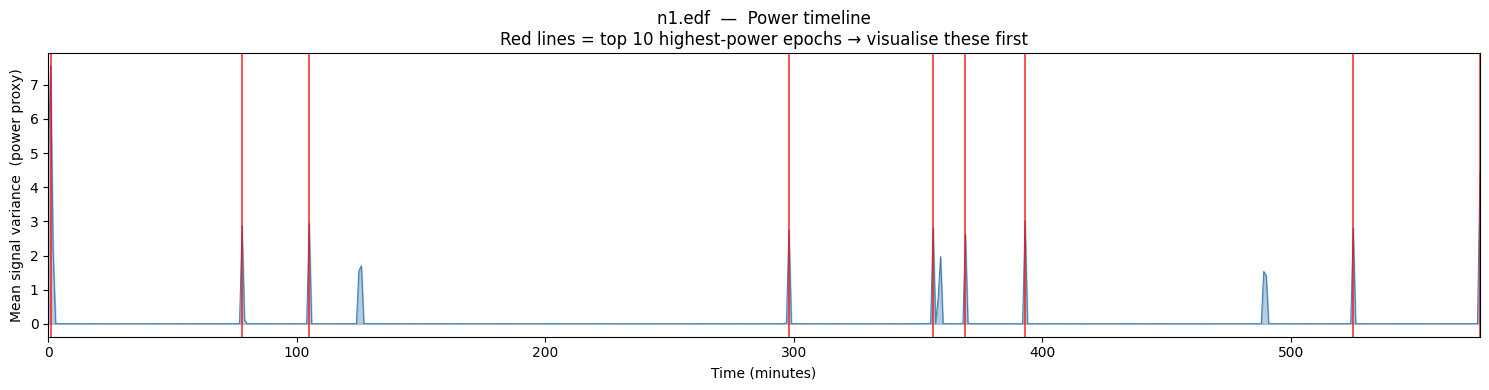


→ Run these epoch_idx values to find red clouds:
  [np.int64(1), np.int64(0), np.int64(576), np.int64(393), np.int64(105), np.int64(78), np.int64(356), np.int64(525), np.int64(298), np.int64(369)]


In [123]:
top_epochs = scan_power("n1.edf", epoch_sec=60.0, top_n=10)

In [126]:
# Quick check — print raw PSD values for epoch 0 and epoch 1
data, sfreq, ch_names = load_edf("n1.edf")
epochs = slice_epochs(data, sfreq, 60.0)

for idx in [0, 1, 576]:
    ep = epochs[idx]
    # mean variance per channel
    var_per_ch = np.var(ep, axis=1)
    print(f"\nepoch {idx}  (t={idx:.0f}–{idx+1:.0f} min)")
    for ch, v in zip(ch_names, var_per_ch):
        print(f"  {ch:<12}  var = {v:.4f}")

C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\1114922158.py:11: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\1114922158.py:11: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\1114922158.py:11: RuntimeWarning: Highpass cutoff frequency 10.0 is greater than lowpass cutoff frequency 3.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


  Channels : ['ROC-LOC', 'LOC-ROC', 'F2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'C4-A1', 'EMG1-EMG2', 'ECG1-ECG2', 'TERMISTORE', 'TORACE', 'ADDOME', 'Dx1-DX2', 'SX1-SX2', 'Posizione', 'HR', 'SpO2']
  sfreq    : 100.0 Hz
  Duration : 34620.0 s

epoch 0  (t=0–1 min)
  ROC-LOC       var = 0.0000
  LOC-ROC       var = 0.0000
  F2-F4         var = 0.0000
  F4-C4         var = 0.0000
  C4-P4         var = 0.0000
  P4-O2         var = 0.0000
  F1-F3         var = 0.0000
  F3-C3         var = 0.0000
  C3-P3         var = 0.0000
  P3-O1         var = 0.0000
  C4-A1         var = 0.0000
  EMG1-EMG2     var = 0.0000
  ECG1-ECG2     var = 0.0000
  TERMISTORE    var = 0.0000
  TORACE        var = 0.0000
  ADDOME        var = 0.0000
  Dx1-DX2       var = 0.0000
  SX1-SX2       var = 0.0000
  Posizione     var = 0.0000
  HR            var = 41.8238
  SpO2          var = 60.5970

epoch 1  (t=1–2 min)
  ROC-LOC       var = 0.0000
  LOC-ROC       var = 0.0000
  F2-F4         

In [125]:
import mne
raw = mne.io.read_raw_edf("n1.edf", preload=True, verbose=False)
print(raw.info)
print("\nChannel names:", raw.ch_names)
print("Physical min/max:")
for i, ch in enumerate(raw.ch_names):
    d = raw.get_data(picks=[i])[0]
    print(f"  {ch:<15}  min={d.min():.6f}  max={d.max():.6f}  "
          f"mean={d.mean():.6f}  var={d.var():.6f}")

C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\3442489695.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("n1.edf", preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\3442489695.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf("n1.edf", preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_1252\3442489695.py:2: RuntimeWarning: Highpass cutoff frequency 10.0 is greater than lowpass cutoff frequency 3.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf("n1.edf", preload=True, verbose=False)


<Info | 8 non-empty values
 bads: []
 ch_names: ROC-LOC, LOC-ROC, F2-F4, F4-C4, C4-P4, P4-O2, F1-F3, F3-C3, ...
 chs: 21 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2009-01-01 22:06:03 UTC
 nchan: 21
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>

Channel names: ['ROC-LOC', 'LOC-ROC', 'F2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'C4-A1', 'EMG1-EMG2', 'ECG1-ECG2', 'TERMISTORE', 'TORACE', 'ADDOME', 'Dx1-DX2', 'SX1-SX2', 'Posizione', 'HR', 'SpO2']
Physical min/max:
  ROC-LOC          min=-0.000408  max=0.000411  mean=-0.000000  var=0.000000
  LOC-ROC          min=-0.000411  max=0.000408  mean=0.000000  var=0.000000
  F2-F4            min=-0.000293  max=0.000560  mean=0.000000  var=0.000000
  F4-C4            min=-0.000361  max=0.000368  mean=0.000000  var=0.000000
  C4-P4            min=-0.000584  max=0.000393  mean=0.000000  var=0.000000
  P4-O2            min=-0.000616  max=0.001000  mean=0.000000  va